In [2]:
import fsrs
from datetime import datetime, timezone
import json
from tqdm import tqdm
from collections import defaultdict
# https://raw.githubusercontent.com/open-spaced-repetition/srs-benchmark/0f70abe71ede66e27ee4c392a72998695ebc48b1/result/FSRS-6.jsonl
with open("FSRS-6-unclamped-decay.jsonl") as f:
    users = [json.loads(s) for s in f.readlines()]


fsrs.Scheduler._validate_parameters = lambda *_, **__: None


In [3]:
dr = 0.7

example_ratings = [tuple(a) for a in [
    [3, 3, 3, 3],
    [3, 3],
    [1, 3, 3, 3],
    [1, 3],
    [1],
    [2],
    [3],
    [4]
]]

decay_bins = defaultdict(lambda: [])

for user in tqdm(users):
    params = user["parameters"]["0"]
    decay = params[20]

    sched = fsrs.Scheduler(params, learning_steps=(), relearning_steps=())
    sched.desired_retention = dr

    for ratings in example_ratings:
        card = fsrs.Card()
        now = datetime.now(timezone.utc)
        for rating in ratings:
            last_review = now
            card, _ = sched.review_card(card, rating, now)
            now = card.due
        interval = now - last_review
        decay_bins[ratings].append((decay, interval.days))
        

    

100%|██████████| 9999/9999 [01:29<00:00, 111.11it/s]


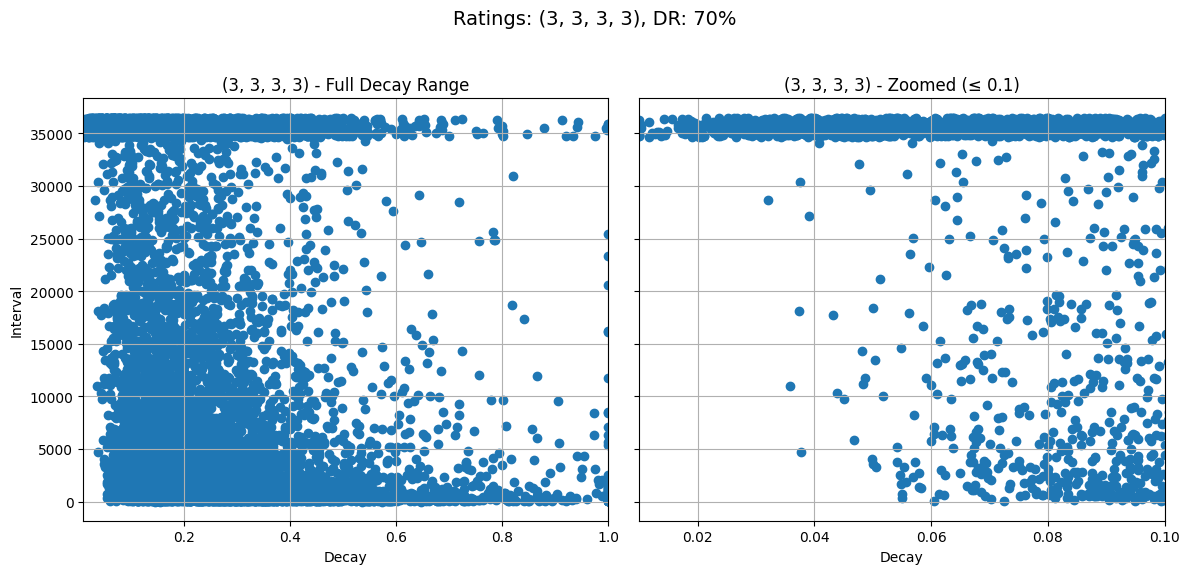

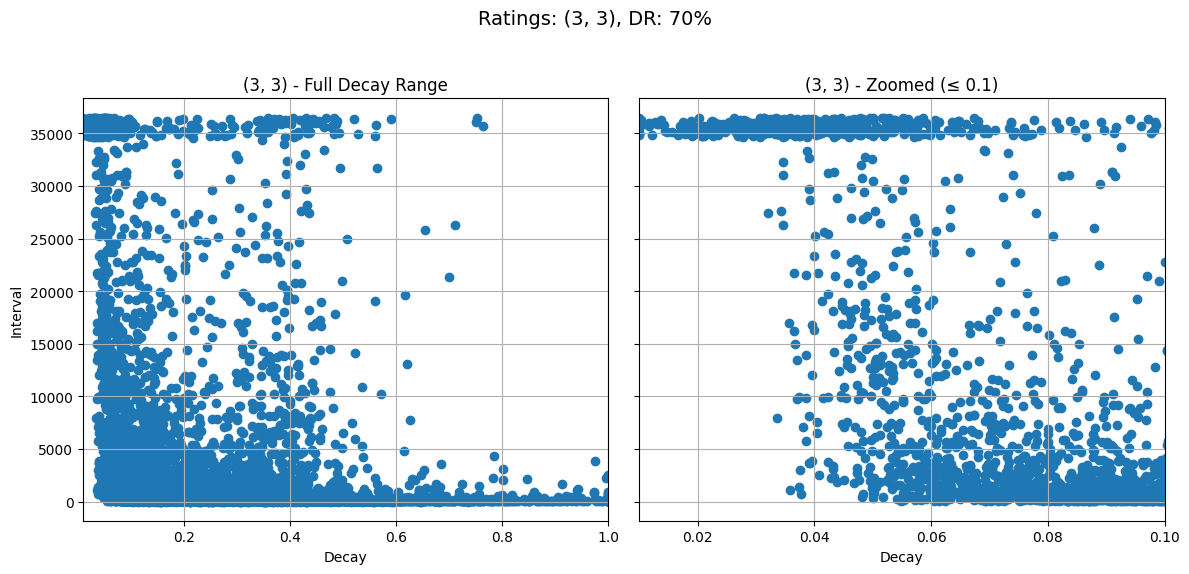

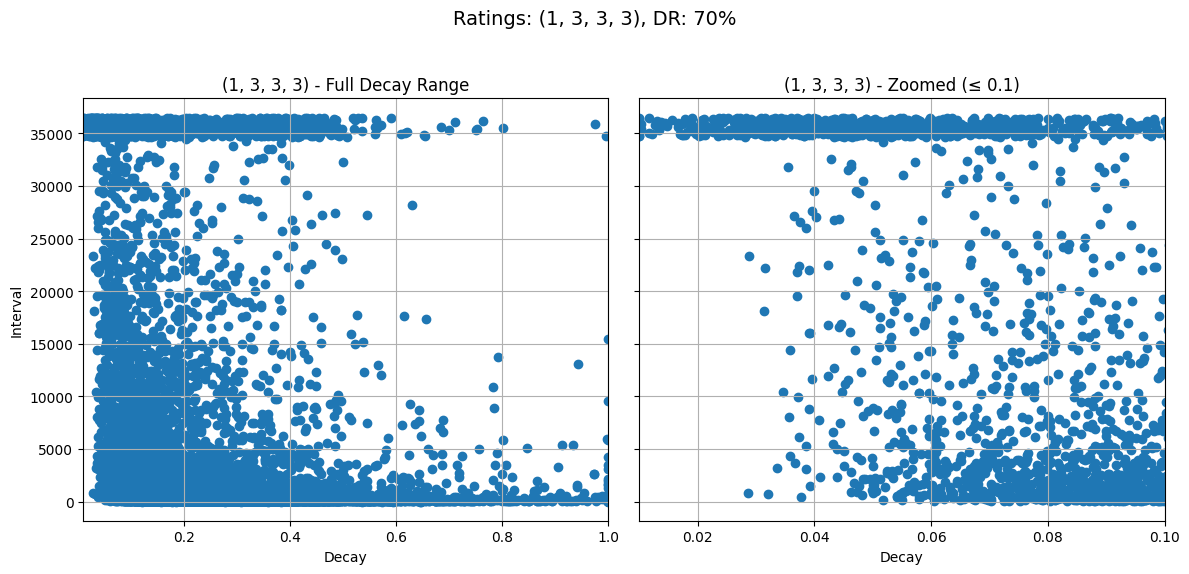

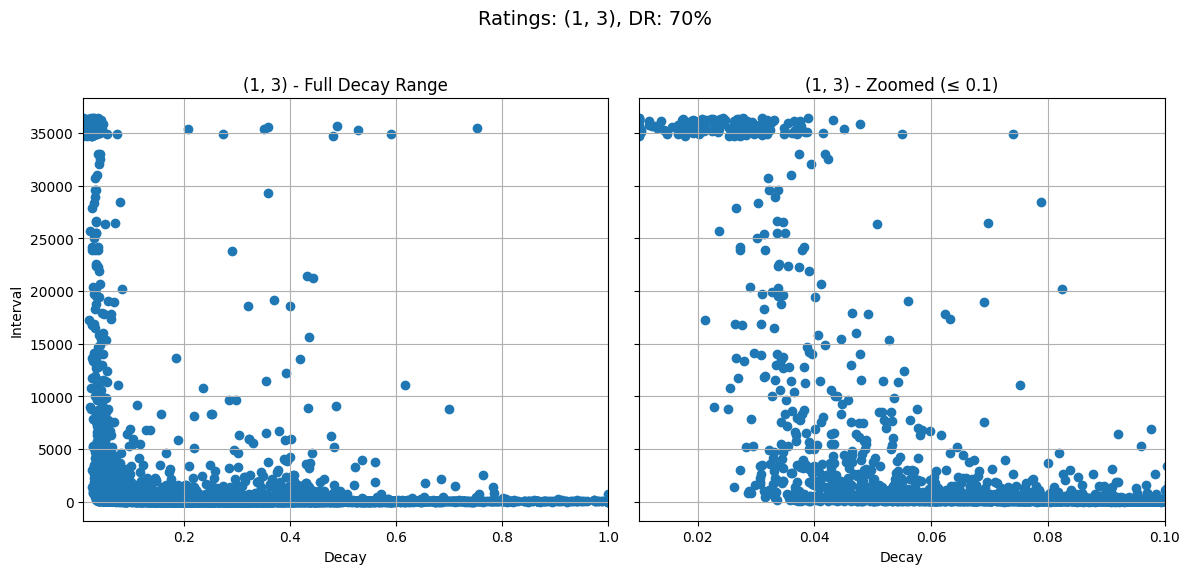

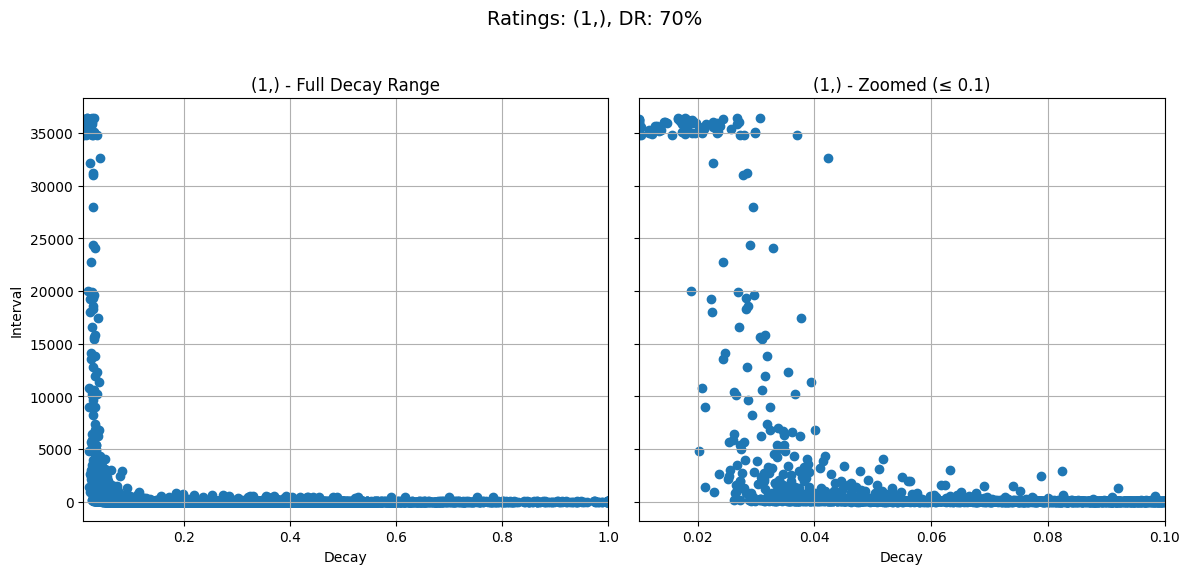

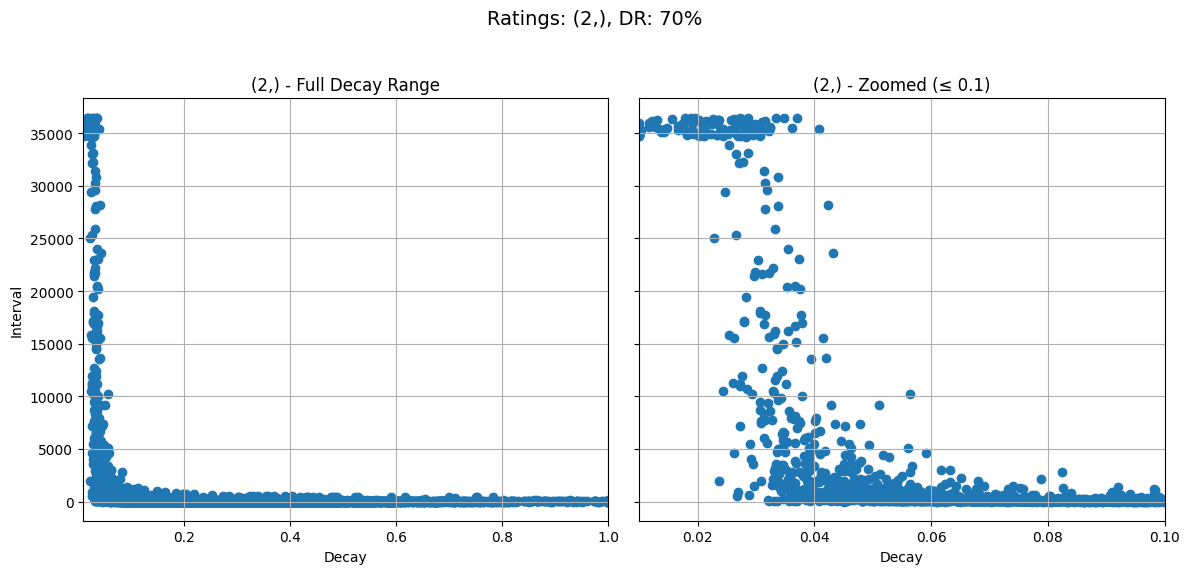

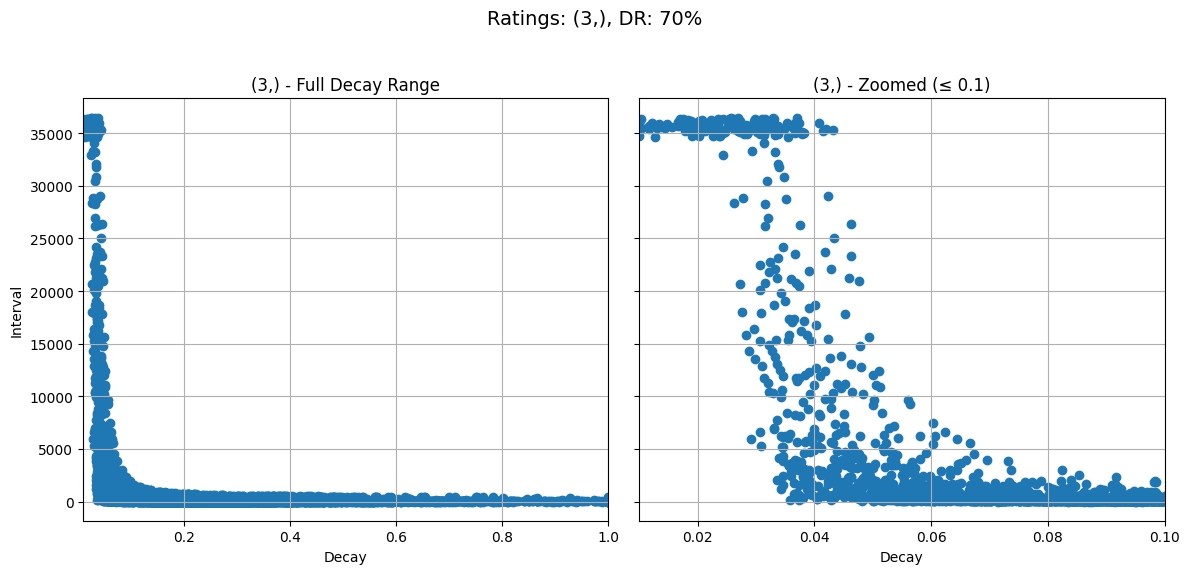

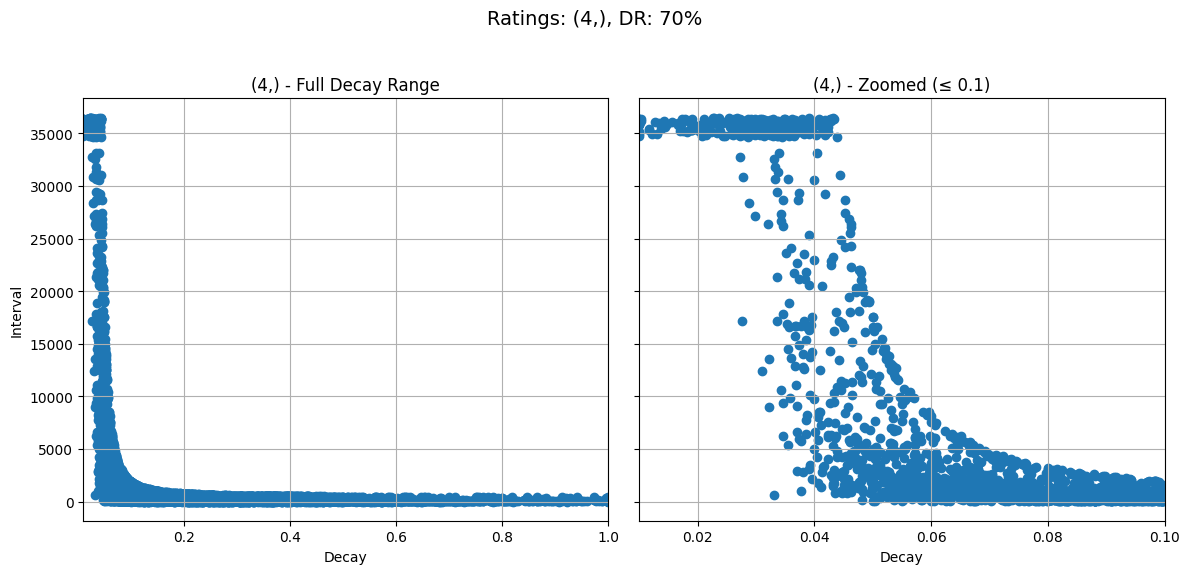

In [ ]:
from matplotlib import pyplot as plt

max_displayed_decay = 0.1

for decay_bin, ratings in decay_bins.items():
    decays, intervals = zip(*ratings)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    # Full range view
    axs[0].scatter(decays, intervals)
    axs[0].set_title(f"{decay_bin} - Full Decay Range")
    axs[0].set_xlabel("Decay")
    axs[0].set_ylabel("Interval")
    axs[0].set_xlim(0.01, 1.0)
    axs[0].grid(True)

    # Zoomed-in view
    axs[1].scatter(decays, intervals)
    axs[1].set_title(f"{decay_bin} - Zoomed (≤ {max_displayed_decay})")
    axs[1].set_xlabel("Decay")
    axs[1].set_xlim(0.01, max_displayed_decay)
    axs[1].grid(True)

    plt.suptitle(f"Ratings: {decay_bin}, DR: {dr:.0%}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
